Такташев Евгений

Импортируем библиотеки

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, classification_report
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import shap

Ставим сид

In [6]:
seed = 2026
np.random.seed = seed

Чтение данных и разделение

In [7]:
df = pd.read_csv('/UCI_Credit_Card.csv')

X = df.drop(['ID', 'default.payment.next.month'], axis=1)
y = df['default.payment.next.month']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed, stratify=y
)

Выберу XGBoost так, как он хорошо подходит для классификаций. Также использую RandomizedSearchCV, потому что он экономит время, а качество конечного результата практически не отличается.  
У меня нет опыта подбора гиперпараметров, поэтому я взял их из примеров с лекций. Также добавил min_child_weight и gamma.

In [11]:
xgb_model = xgb.XGBClassifier(
    random_state=seed,
    eval_metric='auc',
    tree_method='hist'  # быстрее
)

param_dist = {
    'n_estimators': [200, 300, 400, 500, 600],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.005, 0.01, 0.05, 0.1, 0.15],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2]
}

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=seed,
    verbose=1
)

random_search.fit(X_train, y_train)

print("Лучшие параметры:", random_search.best_params_)
print("Лучший CV AUC:", random_search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Лучшие параметры: {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.7}
Лучший CV AUC: 0.7824204413644867


На основе результатов обучим финальную модель

In [12]:
best_xgb = random_search.best_estimator_
best_xgb.fit(X_train, y_train)

# Предсказания
y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:, 1]

print("Test ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

Test ROC-AUC: 0.7884141303977974
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.67      0.34      0.45      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.67      6000
weighted avg       0.80      0.82      0.79      6000



Для визуализаций использую Feature Importance и Shap.

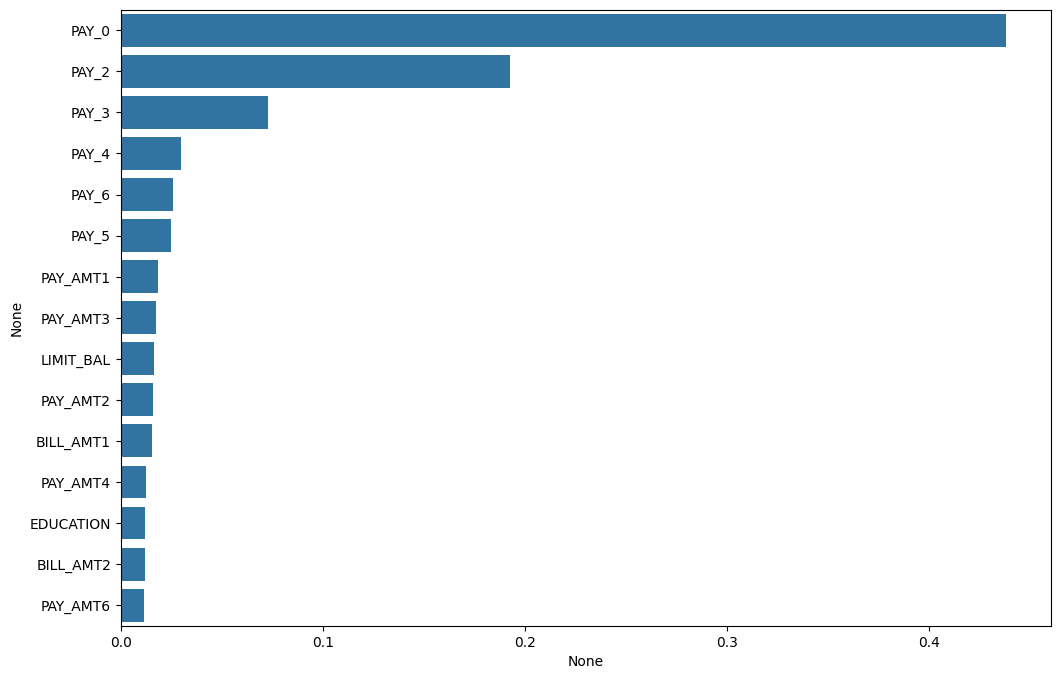

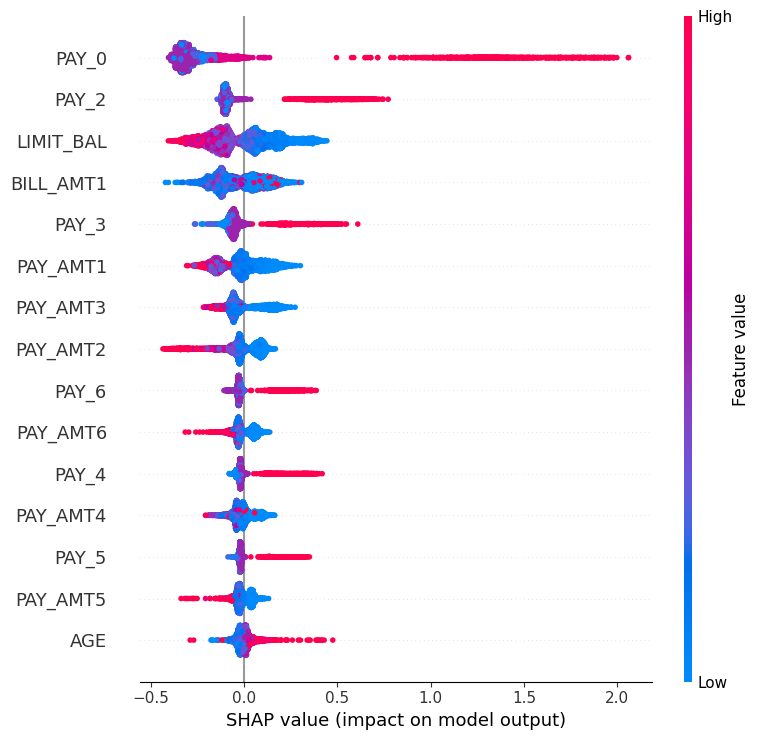

In [15]:

importances = pd.Series(best_xgb.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=importances[:15], y=importances.index[:15])
plt.show()

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, max_display=15)  # beeswarm

По результатам видно, что серия pay ниболеее влиятельная. Особенно, если есть просрочки, то это сильно влияет на оплату в следующем месяце, но также неожиданно, что возраст, статус и образование не сильно влияет, но выделяется ещё limit_bal, возможно, что при большом кредите у банка есть залог, который стимулирует лядей платить на кредит.

А теперь посмотрим как модель считается двух отдельно взятых людей.

Клиент 2 - реальный default: 1


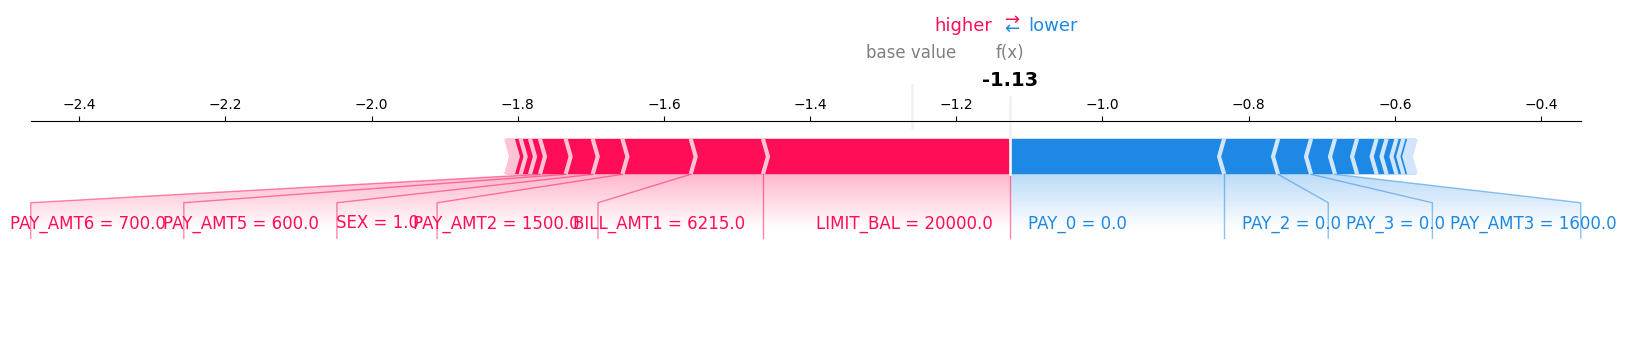

Клиент 10 - реальный default: 0


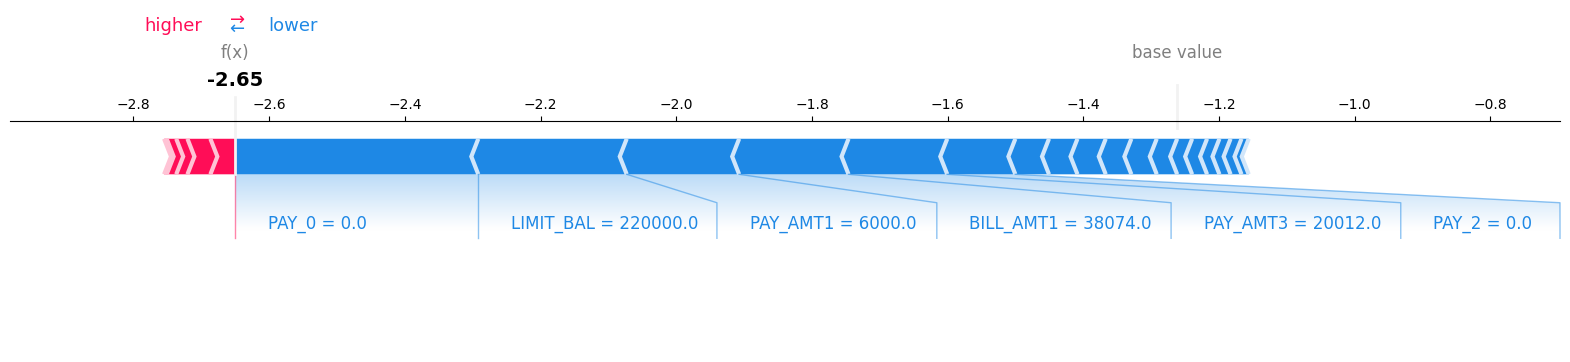

In [17]:
# Пример для двух клиентов
idx1 = 2
idx2 = 10

print("Клиент", idx1, "- реальный default:", y_test.iloc[idx1])
shap.force_plot(explainer.expected_value, shap_values[idx1], X_test.iloc[idx1], matplotlib=True)

print("Клиент", idx2, "- реальный default:", y_test.iloc[idx2])
shap.force_plot(explainer.expected_value, shap_values[idx2], X_test.iloc[idx2], matplotlib=True)

Видно, что маленький размер limit_bal очень сильно вляиет на вероятность дефолта, а большой кредит и оплта прошлого месяца уменьшает эту вероятность.

В итоге можно сделать вывод, что модель хорошо себя показывает, а также её улучшение в сравнении с более простой logisticregression.